In [6]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import torch
from functools import reduce
from numpy.polynomial import chebyshev as C

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
})

In [3]:
n_qubits  = 2
L         = 1
blocks    = 2
n_samples = 10
Nx        = 10

# d = 2**n_qubits
# O = np.zeros((d, d))
# O[0, 0] = 1.0

dev = qml.device("default.qubit", wires=range(n_qubits))

def pauli_encoding(x):
    for w in range(n_qubits):
        qml.RX(x, wires=w)

def novel_exp_encoding(x, layer):
    eta = 3**(n_qubits*layer)
    angle1 = eta * x * 3
    angle2 = eta * x
    qml.RZ((angle1), wires=0)
    qml.RZ((angle2), wires=1)


def Observable_local(n, device='cpu', dtype=torch.float32):
    """
    Returns the operator O_L = (1/n) * sum_j (|0><0|_j ⊗ I_{rest})
    as a 2^n x 2^n tensor.
    """
    # single-qubit projectors and identity
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    # accumulate sum of tensor-products
    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        # build list of n factors: P0 at position j, I elsewhere
        factors = [P0 if k == j else I2 for k in range(n)]
        # take the n-fold Kronecker product
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    # average
    return OL / n

def make_qnode():
    @qml.qnode(dev)
    def circuit(x, weights):
        qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
        for l in range(L):
            # pauli_encoding(x)
            novel_exp_encoding(x, l)
            qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
        # return qml.expval(qml.Hermitian(O, wires=range(n_qubits)))
        O_L = Observable_local(n_qubits).numpy()
        return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    return circuit

circuit = make_qnode()

x_grid = np.linspace(0, 2*np.pi, Nx, endpoint=False)
dx = x_grid[1] - x_grid[0]
# map FFT bins to integer frequencies
freqs = np.fft.fftfreq(Nx, d=dx/(2*np.pi)).astype(int)

# draw random weights
thetas = np.random.uniform(0, 2*np.pi,size=(n_samples, L+1, blocks, n_qubits, 3))

# store all samples of c_ω
coeffs = np.zeros((n_samples, Nx), dtype=complex)
fvals = []
for i in range(n_samples):
    fval = [circuit(x, thetas[i]) for x in x_grid]
    coeffs[i] = np.fft.fft(fval) / Nx
    fvals.append(fval)

# compute Var[c_ω] over samples
uniq_freqs = np.unique(freqs)
var_c = {w: np.var(coeffs[:, freqs==w].real + 1j*coeffs[:, freqs==w].imag)
         for w in uniq_freqs}

y_vals_qfm = np.array([var_c[w] for w in uniq_freqs]) * 1e4

In [4]:
errors = []
# x_grid = np.linspace(0, 2*np.pi, Nx, endpoint=False)
x_grid = np.linspace(-1.2, 4, 200, endpoint=False)
for i in range(n_samples):
    f_reconstructed = np.fft.ifft(coeffs[i] * Nx).real
    fval = fvals[i]
    error = np.linalg.norm(fval - f_reconstructed)
    errors.append(error)

avg_error = np.mean(errors)
std_error = np.std(errors)

print(f"所有样本的平均重构误差 (Average Error): {avg_error:.4e}")
print(f"误差的标准差 (Std Dev): {std_error:.4e}")

所有样本的平均重构误差 (Average Error): 2.9762e-16
误差的标准差 (Std Dev): 1.2080e-16


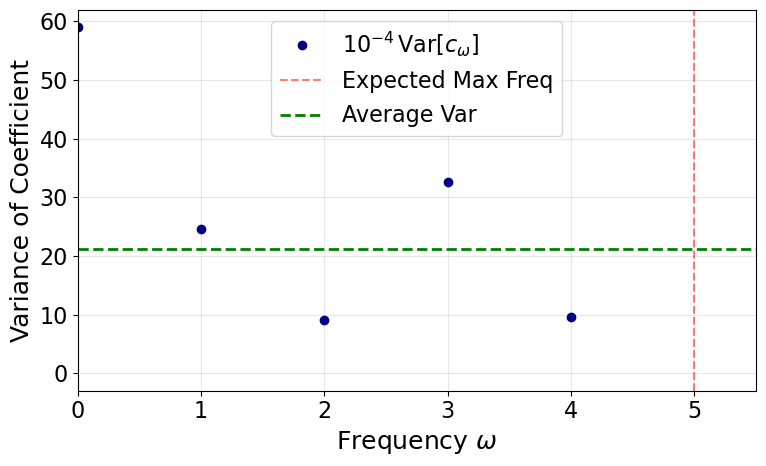

In [5]:
total = len(y_vals_qfm)   # 应该是 120
keep = 10
start = (total - keep) // 2
end   = start + keep

var_mean = np.mean(y_vals_qfm[start:end])

plt.figure(figsize=(8, 5))
plt.plot(uniq_freqs, y_vals_qfm, 'o', color='navy', markersize=6, label=r'$10^{-4}\,\mathrm{Var}[c_\omega]$')
plt.axvline(x=5, color='r', linestyle='--', alpha=0.5, label='Expected Max Freq')
plt.axhline(y=var_mean, color='green', linestyle='--', linewidth=2, label=r'Average Var')
plt.xlim(0, None)
plt.xlabel(r'Frequency $\omega$')
plt.ylabel(r'Variance of Coefficient')
# plt.title(f'Coefficient variance of Quantum fourier models (Exp encoding, qubits = {n_qubits}, layers = {L})')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
n_qubits  = 2
L         = 1
blocks    = 2
n_samples = 10
Nx        = 40
deg_max = 10

# d = 2**n_qubits
# O = np.zeros((d, d))
# O[0, 0] = 1.0

dev = qml.device("default.qubit", wires=range(n_qubits))

def pauli_encoding(x):
    for w in range(n_qubits):
        qml.RX(x, wires=w)

def novel_exp_encoding(x, layer):
    """
    x is assumed in [-1, 1].
    We implement angles proportional to arccos(x),
    so that cos(k arccos(x)) = T_k(x) structure shows up.
    """
    eta = 3**(n_qubits*layer)

    # ✅ 你提出的修改：angle = eta * arccos(x) * const
    phi = np.arccos(x)  # in [0, pi]
    angle1 = eta * phi * 3.0
    angle2 = eta * phi

    qml.RZ(angle1, wires=0)
    qml.RZ(angle2, wires=1)

def Observable_local(n, device='cpu', dtype=torch.float32):
    """
    Returns the operator O_L = (1/n) * sum_j (|0><0|_j ⊗ I_{rest})
    as a 2^n x 2^n tensor.
    """
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    return OL / n

def make_qnode():
    @qml.qnode(dev)
    def circuit(x, weights):
        qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
        for l in range(L):
            # pauli_encoding(x)
            novel_exp_encoding(x, l)
            qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
        O_L = Observable_local(n_qubits).numpy()
        return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    return circuit

circuit = make_qnode()


x_grid = np.linspace(-0.99, 0.99, Nx, endpoint=False)
thetas = np.random.uniform(0, 2*np.pi, size=(n_samples, L+1, blocks, n_qubits, 3))

coeffs_cheb = np.zeros((n_samples, deg_max + 1), dtype=float)
fvals = []

for i in range(n_samples):
    fval = np.array([circuit(x, thetas[i]) for x in x_grid], dtype=float)
    a = C.chebfit(x_grid, fval, deg=deg_max)  # a[0..deg_max]
    fvals.append(fval)
    coeffs_cheb[i] = a

var_a = np.var(coeffs_cheb, axis=0)
orders = np.arange(deg_max + 1)

In [10]:
errors = []
# x_grid = np.linspace(-0.99, 0.99, Nx, endpoint=False)
for i in range(n_samples):
    cheb_poly = C.Chebyshev(coeffs_cheb[i])
    f_reconstructed = cheb_poly(x_grid)
    fval = fvals[i]
    error = np.linalg.norm(fval - f_reconstructed)
    errors.append(error)

avg_error = np.mean(errors)
std_error = np.std(errors)

print(f"所有样本的平均重构误差 (Average Error): {avg_error:.4e}")
print(f"误差的标准差 (Std Dev): {std_error:.4e}")

所有样本的平均重构误差 (Average Error): 3.2292e-03
误差的标准差 (Std Dev): 1.6085e-03


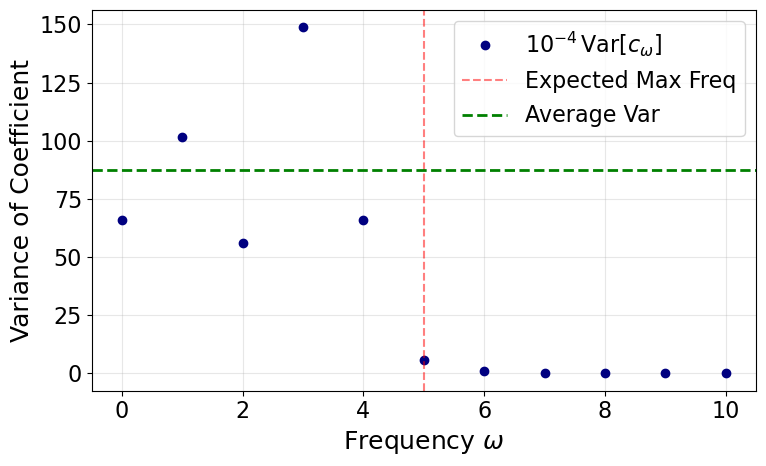

In [11]:
orders = np.arange(deg_max + 1)
scale = 1e4
cutoff = 5
y_vals_qcm = var_a * scale
var_mean = np.mean(y_vals_qcm[:cutoff])

plt.figure(figsize=(8, 5))
plt.plot(orders, y_vals_qcm, 'o', color='navy', markersize=6, label=r'$10^{-4}\,\mathrm{Var}[c_\omega]$')
plt.axvline(x=cutoff, color='r', linestyle='--', alpha=0.5, label='Expected Max Freq')
plt.axhline(y=var_mean, color='green', linestyle='--', linewidth=2, label=r'Average Var')
plt.xlabel(r'Frequency $\omega$')
plt.ylabel(r'Variance of Coefficient')
# plt.title(f'Coefficient variance of Quantum chebyshev models (Exp encoding, qubits = {n_qubits}, layers = {L})')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Second Coefficient method

In [12]:

# ================= 配置参数 =================
n_qubits  = 2
L         = 1
blocks    = 2
n_samples = 10
Nx = 20
deg_max   = 20  # 即使设置很高，因为使用了 interpolate，也不会崩坏

# ================= 量子电路定义 =================
dev = qml.device("default.qubit", wires=range(n_qubits))

def novel_exp_encoding(x, layer):
    """
    x in [-1, 1].
    angle = eta * arccos(x) * const
    """
    eta = 3**(n_qubits*layer)
    phi = np.arccos(x)
    angle1 = eta * phi * 3.0
    angle2 = eta * phi

    qml.RZ(angle1, wires=0)
    qml.RZ(angle2, wires=1)

def Observable_local(n, device='cpu', dtype=torch.float32):
    P0 = torch.tensor([[1., 0.], [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)
    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j
    return OL / n

@qml.qnode(dev)
def circuit(x, weights):
    qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
    for l in range(L):
        novel_exp_encoding(x, l)
        qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
    O_L = Observable_local(n_qubits).numpy()
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

# ================= 数据生成 =================
# 用于最后的验证集 (Verification Grid)
x_grid = np.linspace(-0.99, 0.99, Nx, endpoint=False)

# 随机参数
thetas = np.random.uniform(0, 2*np.pi, size=(n_samples, L+1, blocks, n_qubits, 3))

# 存储系数
coeffs_cheb = np.zeros((n_samples, deg_max + 1), dtype=float)

print(f"开始计算... (使用 Chebyshev.interpolate, Degree={deg_max})")

# ================= 核心修改部分 =================
for i in range(n_samples):
    def target_function(x_input):
        if np.isscalar(x_input):
            return circuit(x_input, thetas[i])
        else:
            return np.array([circuit(x, thetas[i]) for x in x_input])

    # 2. 使用 interpolate
    # 这会自动计算最优采样点，并执行插值，得到最精确的系数
    poly = C.Chebyshev.interpolate(target_function, deg=deg_max, domain=[-1, 1])

    # 3. 保存系数
    # poly.coef 的长度就是 deg_max + 1
    coeffs_cheb[i] = poly.coef

print("计算完成。")

开始计算... (使用 Chebyshev.interpolate, Degree=20)
计算完成。


In [16]:
errors = []
y_vals_qcm2 = []

for i in range(n_samples):
    cheb_poly = C.Chebyshev(coeffs_cheb[i])
    f_reconstructed = cheb_poly(x_grid)
    f_true = np.array([circuit(x, thetas[i]) for x in x_grid])
    y_vals_qcm2.append(f_true)
    error = np.linalg.norm(f_true - f_reconstructed)
    errors.append(error)

avg_error = np.mean(errors)
print(f"========================================")
print(f"验证集上的平均重构误差: {avg_error:.4e}")
print(f"========================================")

验证集上的平均重构误差: 2.0198e-03


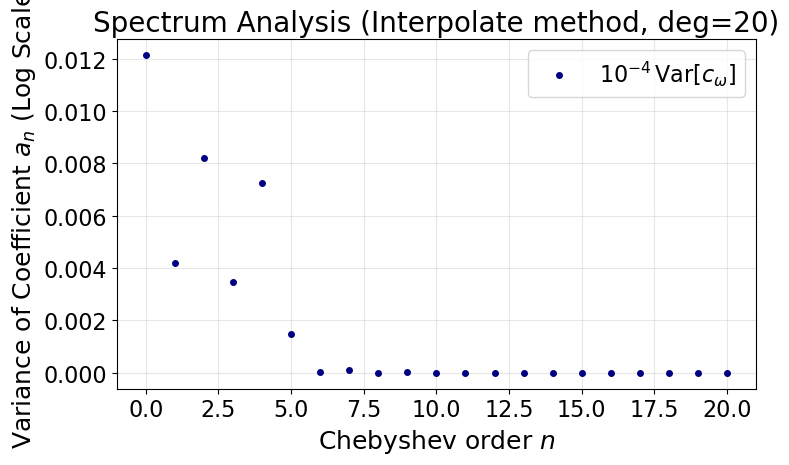

In [21]:
var_a = np.var(coeffs_cheb, axis=0)
orders = np.arange(deg_max + 1)
y_vals = var_a

plt.figure(figsize=(8, 5))
plt.plot(orders, var_a, 'o', color='navy', markersize=4, label=r'$10^{-4}\,\mathrm{Var}[c_\omega]$')
# plt.semilogy(orders, var_a, 'o-', color='navy', markersize=4, label='Var[a_n]')
# plt.axvline(x=40, color='r', linestyle='--', alpha=0.5, label='Approx. Max Quantum Freq')
plt.xlabel(r'Chebyshev order $n$')
plt.ylabel(r'Variance of Coefficient $a_n$ (Log Scale)')
plt.title(f'Spectrum Analysis (Interpolate method, deg={deg_max})')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()